# RFSoC Spectrum Sweep
----
<div class="alert alert-box alert-info">
Please use Jupyter labs http://board_ip_address/lab for this notebook.
</div>

A simple way of validating the operation of the RF Data Converters
(RF DCs) on your ZCU216 board is to perform a spectrum sweep. 
The spectrum sweep is the process of transmitting a series of
tones and confirming that they are all received correctly.

## Aims
* Review basic tone generation using the RF DAC channels.
* Demonstrate a simple Spectrum Analyzer using the RF ADC channels.
* Use the tone generator and Spectrum Analyzer to perform a spectrum sweep.

## Table of Contents
* [Hardware Setup](#hardware-setup)
* [Application Setup and Design](#application-setup-and-design)
    * [Basic Tone Generation](#basic-tone-generation)
    * [A Spectrum Analyser](#a-spectrum-analyser)
* [The Spectrum Sweep](#the-spectrum-sweep)
    * [Setting Constraints](#setting-constraints)
    * [Useful Measurements](#useful-measurements)
    * [Running the Sweep](#running-the-sweep)
    * [Analysing Results](#analysing-results)
* [Conclusion](#conclusion)

## References
* [Xilinx, Inc, "USP RF Data Converter: LogiCORE IP Product Guide", PG269, v2.4, November 2020](https://www.xilinx.com/support/documentation/ip_documentation/usp_rf_data_converter/v2_4/pg269-rf-data-converter.pdf)
* [Xilinx, Inc, "ZCU208 Evaluation Board User Guide", UG1410, v1.0, July 2020](https://www.xilinx.com/support/documentation/boards_and_kits/zcu208/ug1410-zcu208-eval-bd.pdf)
* [Xilinx, Inc, "CLK104 RF Clock Add-on Card", UG1437, v1.0, March 2020](https://japan.xilinx.com/support/documentation/boards_and_kits/zcu216/ug1437-clk104.pdf)
* [Cooley, James W.; Tukey, John W. (1965). "An algorithm for the machine calculation of complex Fourier series". Mathematics of Computation. 19 (90): 297–301.](https://www.ams.org/journals/mcom/1965-19-090/S0025-5718-1965-0178586-1/home.html)

## Revision History

* v1.0 | 10/02/2021 | First notebook revision.
* v2.0 | 23/09/2021 | Revised for the ZCU208.

----

## Hardware Setup <a class="anchor" id="hardware-setup"></a>
The hardware setup necessary for this notebook is covered in the <a href="./01_rf_dataconverter_introduction.ipynb">RF Dataconverter Introduction</a>.  Please refer to it before continuing further.

<div class="alert alert-heading alert-danger">
    <h4 class="alert-heading">Warning:</h4>

In this demo we are transmitting signals via cables.
This device can also transmit wireless signals. 
Keep in mind that unlicensed transmission of wireless signals
may be illegal in your location. 
Radio signals may also interfere with nearby devices,
such as pacemakers and emergency radio equipment. 
If you are unsure, please seek professional support.
</div>

----

## Application Setup and Design <a class="anchor" id="application-setup-and-design"></a>

The spectrum sweep application needs two major components to operate effectively.
A tone generator that creates frequency stimulus, and a spectrum analysis
tool such as a Spectrum Analyser. We will design and setup each of these
components and then perform the spectrum sweep application.

To begin we will download the base overlay.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
from pynq.overlays.base import BaseOverlay
#base = BaseOverlay('base.bit')
base = BaseOverlay('../out/base.bit')

The ZCU208 has a sophisticated clocking network, which can generate
low-jitter clocks for the RF DC Phase-Locked Loops (PLLs). This clocking 
network is contained on the CLK104 add-on card and is passed to the ZCU216 RF DC via SMA cables. 

The base overlay has a simple method to initialize these clocks. Run the cell below to set
the LMK and LMX clocks to 245.76MHz and 491.52MHz, respectively.

In [3]:
#base.init_rf_clks()

### Basic Tone Generation <a class="anchor" id="basic-tone-generation"></a>
Tone generation has been covered before in previous notebooks, however, 
we require it again to perform the spectrum sweep application. 

Lets first obtain the ToneGenerator class from `rfsystem.spectrum_sweep` and
create a ToneGenerator for each channel in the system.

In [4]:
from rfsystem.spectrum_sweep import ToneGenerator

generators = []
for i in range(0, len(base.radio.transmitter.channel)):
    generators.append(
        ToneGenerator(channel=base.radio.transmitter.channel[i]))

Now we can initialise each tone generator with a centre frequency and gain.

In [30]:
for generator in generators:
    generator.frequency_selector.centre_frequency = 400 # MHz
    generator.amplitude_controller.enable = True
    generator.amplitude_controller.gain = 0.5

Although the RF DAC can produce a tone of a desired center frequency,
one should keep in mind that the tone folds through the RF DAC Nyquist Zones.
While you may be transmitting a 600 MHz tone, as in the above code cell, 
you are also transmitting another tone at 4315.2 MHz (due to a sample frequency
of 4915.2 MSPS). External RF filtering is required to suppress unwanted tones
in neighboring Nyquist Zones.

### A Spectrum Analyser <a class="anchor" id="a-spectrum-analyser"></a>

A simple method of inspecting a signal is to perform an FFT and
analyze it in the frequency domain. A Spectrum Analyzer class has been
created for this very purpose in `rfsystem.spectrum_sweep`. Let's import it
and create a spectrum analyzer for each receiver channel.

In [33]:
#import ipywidgets as ipw
from rfsystem.spectrum_sweep import SpectrumAnalyser
#
analysers = []
sample_frequency = 2457.6e6
number_samples = 12288
for i in range(0, len(base.radio.receiver.channel)):
    analysers.append(
        SpectrumAnalyser(channel = base.radio.receiver.channel[i],
                         sample_frequency = sample_frequency,
                         number_samples = number_samples,
                         title = ''.join(['Spectrum Analyser Channel ',
                                          str(i)]),
                         height = None,
                         width = None))

#ipw.VBox([analyser.spectrum_plot.get_plot() for analyser in analysers])

In [35]:
#fig, axes = plt.subplots(num_channels, 1, figsize=(10, 5 * num_channels))
#fig.suptitle('Live Spectrum Analyser Simulation', fontsize=16, fontweight='bold')
#plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle

# The list comprehension and ipw.VBox is replaced by iterating and calling the plot method.
print("Generating Matplotlib spectrum plots for each channel...")

for analyser in analysers:
    # This call generates and displays a Matplotlib figure for each analyser
    analyser.spectrum_plot.get_plot()

# Finally, plt.show() is called to ensure all generated figures are rendered (especially in scripts)
plt.show()

Generating Matplotlib spectrum plots for each channel...


In [18]:
sample_frequency = 2457.6e6
number_samples = 12288
from rfsystem.spectrum_sweep import SpectrumAnalyser

In [19]:
class MockSpectrumPlot:
    """
    Mock class to simulate the plotting object held by the Analyser.
    Its 'get_plot' method handles the Matplotlib drawing.
    """
    def __init__(self, data, freq_axis, title):
        self.data = data
        self.freq_axis = freq_axis
        self.title = title

    def get_plot(self):
        """
        Generates and displays the Matplotlib figure for the spectrum.
        """
        plt.figure(figsize=(10, 5))
        
        # Plot the data
        plt.plot(self.freq_axis, self.data, color='#0077b6', linewidth=1.5)
        
        # Apply labels and titles
        plt.title(self.title, fontsize=14, fontweight='bold')
        plt.xlabel('Frequency (Hz)', fontsize=12)
        plt.ylabel('Power Spectral Density (dBm)', fontsize=12)
        
        # Configure the x-axis to use scientific notation for large frequencies
        plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        # In a non-interactive environment, we explicitly return a placeholder
        # but in a Jupyter/IPython context, calling this function displays the plot.
        return None 
    
#class SpectrumAnalyser:
#    """
#    Mock class that simulates the rfsystem.spectrum_sweep.SpectrumAnalyser.
#    It calculates mock PSD data and sets up the plotting object.
#    """
#    def __init__(self, channel, sample_frequency, number_samples, title, ax):
#        self.channel = channel
#        self.fs = sample_frequency
#        self.N = number_samples
#        self.title = title
#        self.ax = ax # Matplotlib Axes object for this subplot
#        
#        # Calculate center frequency (fc)
#        freq_mhz = channel.adc_block.MixerSettings['Freq']
#        self.fc = round(abs(freq_mhz)) * 1e6
#        
#        # Initialize the data and line plot
#        self.psd_data, self.freq_axis = self._generate_mock_psd()
#        self.line, = self.ax.plot(self.freq_axis, self.psd_data, 
#                                  color='#2a9d8f', linewidth=1.5)
#
#        # Set up subplot appearance
#        self.ax.set_title(self.title, fontsize=12)
#        self.ax.set_xlabel('Frequency (Hz)')
#        self.ax.set_ylabel('PSD (dBm)')
#        self.ax.grid(True, linestyle=':', alpha=0.6)
#        # Use scientific notation for large frequencies
#        self.ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
#
#    def _generate_mock_psd(self, iteration=0):
#        """Generates realistic-looking mock PSD data, with slight random shifts."""
#        noise_floor = -120 # dBm
#        peak_power = 20 # dB
#
#        # Frequency axis centered around fc
#        freq_axis = np.linspace(-self.fs / 2, self.fs / 2, self.N, endpoint=False) + self.fc
#        
#        # Apply a small, time-varying frequency drift for simulation
#        drift = 50e3 * np.sin(iteration * 0.5 + self.channel.adc_block.MixerSettings['Freq'] / 100)
#        
#        # Calculate a signal peak that shifts over time
#        signal_bandwidth = 100e3 
#        signal_peak = peak_power * np.exp(-((freq_axis - self.fc - drift) / signal_bandwidth)**2)
#        
#        # Total PSD: noise floor + signal + random thermal noise
#        psd = noise_floor + signal_peak + 3 * np.random.randn(self.N)
#        return psd, freq_axis
#    
#    def update_spectrum(self, iteration):
#        """
#        Simulates the analyser.update_spectrum() method by generating new
#        data and updating the plot line.
#        """
#        # Generate new data based on the current iteration
#        new_psd_data, _ = self._generate_mock_psd(iteration)
#        
#        # Update the Line2D object with the new data
#        self.line.set_ydata(new_psd_data)


Generating Matplotlib spectrum plots for each channel...


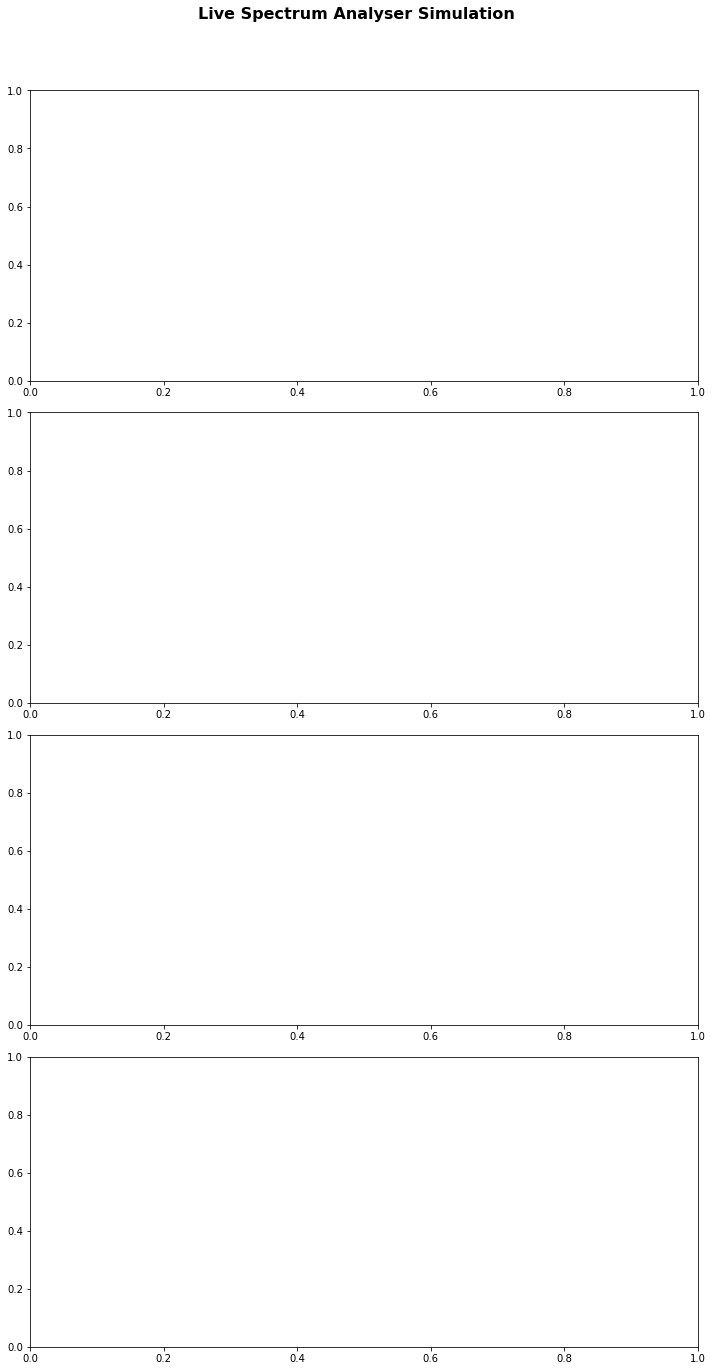

In [24]:
# Set up the main figure with subplots (one for each analyser)
num_channels = len(base.radio.receiver.channel)
fig, axes = plt.subplots(num_channels, 1, figsize=(10, 5 * num_channels))
fig.suptitle('Live Spectrum Analyser Simulation', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle

# Ensure axes is an array even for a single channel
if num_channels == 1:
    axes = [axes]

# Define required parameters
saadc_blockuency = 2457.6e6
number_samples = 12288
analysers = []
for i in range(0, len(base.radio.receiver.channel)):
    analysers.append(
        SpectrumAnalyser(
            channel = base.radio.receiver.channel[i],
            sample_frequency = sample_frequency,
            number_samples = number_samples,
            title = f'Spectrum Analyser Channel {i}',
            #ax = axes[i] # Assign the subplot axis
            height = None,
            width = None
        )
    )

# The list comprehension and ipw.VBox is replaced by iterating and calling the plot method.
print("Generating Matplotlib spectrum plots for each channel...")

for analyser in analysers:
    # This call generates and displays a Matplotlib figure for each analyser
    analyser.update_spectrum()

# Finally, plt.show() is called to ensure all generated figures are rendered (especially in scripts)
plt.show()

You will now see two spectrum plots on your screen. We can animate these plots by running the code cell below.

In [54]:
#import time
#
#for i in range(0, 20):
#    for analyser in analysers:
#        analyser.update_spectrum()
#    time.sleep(0.2)

In [12]:
plt.ion() # Turn on interactive mode for live updates

In [13]:
# --- The Time-Based Update Loop ---

print(f"Starting spectrum update loop for {len(base.radio.receiver.channel)} channels...")
print("Running 20 iterations, updating every 0.2 seconds...")

for i in range(0, 2):
    for analyser in analysers:
        # Calls the method that regenerates data and updates the plot line
        analyser.update_spectrum(i)
    
    # Redraw the plot (mandatory in interactive mode)
    fig.canvas.draw()
    # Briefly pause to allow the GUI event loop to process updates
    plt.pause(0.001) 
    
    # Pause for the requested duration before the next update
    time.sleep(0.02)
    print(f"Iteration {i+1} complete.")

# Keep the final plot displayed after the loop finishes
plt.ioff() # Turn off interactive mode
#plt.show()
plt.show(block=True) # Block execution to keep the final window open

print("Simulation finished.")

Starting spectrum update loop for 4 channels...
Running 20 iterations, updating every 0.2 seconds...
Iteration 1 complete.
Iteration 2 complete.
Simulation finished.


Excellent! You have just explored a software defined spectrum analyzer. 
It will be useful if you right click the above plots and select
`Create new view for output`. This will give the spectrum analyzers their own
window. You will be able to see them at all times when scrolling through the
remainder of this notebook.

## The Spectrum Sweep <a class="anchor" id="the-spectrum-sweep"></a>

We have created a tone generator and spectrum analyzer for each channel.
The next stage is to perform the spectrum sweep and validate the operation of
the RF DCs.

### Setting Constraints <a class="anchor" id="setting-constraints"></a>
We need to define the boundaries of our spectrum sweep application.
What frequencies will we test? At which power should the tone generator
operate at? We can set these parameters below.

In [14]:
frequency_list = [100, 200, 300, 400, 500, 600, 40, 50, 60, 110]
#frequency_list = [200, 600, 1000, 1600, 2600, 3200, 3600, 4200, 4400, 4800]
transmitter_amplitude = 0.5

### Useful Measurements <a class="anchor" id="useful-measurements"></a>

We should consider the measurements during the spectrum sweep. 

* Spurious Free Dynamic Range (SFDR) (the different between the maximum
  and the average power of the spectrum, excluding harmonics and direct current). 
* The fundamental frequency of the received spectrum.

Both of the above measurements are defined in the methods below.

In [15]:
import numpy as np

def calculate_simple_sfdr(spectrum):
    return np.max(spectrum) - np.average(spectrum)

def calculate_fundamental(spectrum, sample_frequency, number_samples, 
                          receive_frequency):
    rbw = sample_frequency/number_samples
    maxindex = np.argsort(spectrum)[-1:][0]
    return maxindex * rbw + receive_frequency - sample_frequency/2

### Running the Sweep <a class="anchor" id="running-the-sweep"></a>

To run the sweep, we need to iterate through all of the frequencies in
`frequency_list` at least once for each channel. The tone generator will
need to be set to the appropriate frequency and the spectrum analyzer needs
to be in the correct Nyquist Zone. 

We have created the spectrum sweep below.

In [16]:
import time

def run_spectrum_sweep(frequencies = frequency_list,
                       amplitude = transmitter_amplitude):
    fundamental = []
    sfdr = []
    results = []
    frequency_zones = [1228.8, 3686.4]
    for frequency in frequencies:
        for generator in generators:
            generator.amplitude_controller.enable = True
            generator.amplitude_controller.gain = amplitude
            generator.frequency_selector.centre_frequency = frequency

        time.sleep(1)

        for analyser in analysers:
            if frequency*1e6 < sample_frequency:
                receive_frequency = frequency_zones[0]
            else:
                receive_frequency = frequency_zones[1]
    
            analyser.frequency_selector.centre_frequency = receive_frequency
            analyser.spectrum_plot.centre_frequency = receive_frequency*1e6
            analyser.update_spectrum()
            spectrum = analyser.get_spectrum()
            maxvalue = np.max(spectrum)
            maxindex = np.argsort(spectrum)[-1:][0]
            fundamental.append(
                calculate_fundamental(
                    spectrum, sample_frequency, number_samples, 
                    receive_frequency*1e6)*1e-6)
            sfdr.append(calculate_simple_sfdr(spectrum))

    for i in range(0, len(analysers)):
        results.append(
            np.array([frequencies, fundamental[i::len(analysers)], 
                      sfdr[i::len(analysers)]]))

    return results

Running the following code cell will execute the spectrum sweep application.
It will take some time to complete. 

While you wait, you can inspect the spectrum analyzer plots.

In [17]:
results = run_spectrum_sweep()

AttributeError: 'SpectrumAnalyser' object has no attribute 'frequency_selector'

### Analysing Results <a class="anchor" id="analysing-results"></a>

Previously we had defined our measurements to be the SFDR, and the fundamental
frequency of the received signal. Let's inspect these measurements now. 

In [15]:
import pandas as pd

for i in range(len(base.radio.receiver.channel)):
    print(''.join(['Channel: ', str(i)]))
    dataframe = pd.DataFrame(
        data=results[i], index=[
            "TX Frequency (MHz)", "RX Fundamental (MHz)", "SFDR (dB)"])
    display(dataframe)

Channel: 0


,0,1,2,3,4,5,6,7,8,9
TX Frequency (MHz),100.000000,200.00000,300.000000,400.000000,500.000000,600.000000,40.00000,50.000000,60.000000,110.000000
RX Fundamental (MHz),1128.800000,200.00000,300.000000,400.000000,1728.800000,600.000000,0.00000,2407.600000,1168.800000,2347.600000
SFDR (dB),28.744101,32.40626,35.665209,36.825191,38.927741,72.664655,26.24044,21.934223,24.643714,25.761108


Channel: 1


,0,1,2,3,4,5,6,7,8,9
TX Frequency (MHz),100.0000,200.000000,300.000000,400.000000,500.000000,600.000000,40.000000,50.000000,60.000000,110.000000
RX Fundamental (MHz),0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SFDR (dB),26.1688,28.909922,27.069665,22.778485,27.379858,25.171172,29.519654,28.612478,25.443752,29.181437


Channel: 2


,0,1,2,3,4,5,6,7,8,9
TX Frequency (MHz),100.000000,200.000000,300.000000,400.000000,500.000000,600.000000,40.000000,50.000000,60.00000,110.000000
RX Fundamental (MHz),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1228.800000
SFDR (dB),22.465741,23.531192,25.063097,20.131063,21.964873,24.053198,20.625252,25.301983,27.27681,22.648404


Channel: 3


,0,1,2,3,4,5,6,7,8,9
TX Frequency (MHz),100.000000,200.000000,300.000000,400.000000,500.000000,600.000000,40.000000,50.000000,60.000000,110.000000
RX Fundamental (MHz),0.000000,0.000000,0.000000,0.000000,1228.800000,1228.800000,0.000000,2457.400000,0.000000,0.000000
SFDR (dB),25.698343,19.578758,22.060938,22.305897,17.939275,18.503146,17.080719,13.652396,21.822884,14.087316


For configuration one, Channels 0 and 1 would have valid results.  Configuration two results would Channels 2 and 3.

For the settings given in this notebook, a suitable SFDR is any value
above 40 dB. The fundamental frequency of the received signal should be
exactly the same as the frequency of the transmitted tone.

## Conclusion <a class="anchor" id="conclusion"></a>
We presented a spectrum sweep application on RFSoC.
You have learned how to setup the spectrum sweep application
using loopback between a tone generator and spectrum analyzer
for each channel. The SFDR and fundamental frequency was measured
for several candidate transmitter frequencies.

[⬅️ Spectrum Analysis on RFSoC](02_B_rf_spectrum_analysis.ipynb)

Copyright (C) 2021 Xilinx, Inc

SPDX-License-Identifier: BSD-3-Clause

----

----